## 0. Notebook Overview

This notebook walks through an exploratory analysis of the synthetic CO2 dataset for cereal by-products.

The goal here is practical: understand the structure of the data, review its quality, and inspect key patterns before modeling. Each section introduces one check or visualization and then explains what to look at in the output.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

candidate_paths = [
    Path("../../data/processed/dataset_optimization_cereal_co2.csv"),
    Path("../data/processed/dataset_optimization_cereal_co2.csv"),
    Path("data/processed/dataset_optimization_cereal_co2.csv")
]

dataset_path = next((p for p in candidate_paths if p.exists()), None)
if dataset_path is None:
    raise FileNotFoundError("Could not locate dataset_optimization_cereal_co2.csv from current working directory.")

df = pd.read_csv(dataset_path)
figures_dir = dataset_path.resolve().parents[2] / "data" / "EDA"
figures_dir.mkdir(parents=True, exist_ok=True)

print(f"Dataset path: {dataset_path.resolve()}")
print(f"Shape: {df.shape}")

Dataset path: C:\Users\IA\Desktop\Proyectos\DATAGIA\a33-cnp-cereals-neuroevolutivo-reduccion-ambiental-residuos\data\processed\dataset_optimization_cereal_co2.csv
Shape: (50000, 8)


## 1. Data Summary

This section gives a quick statistical snapshot of the dataset.

The first table summarizes only numeric variables, while the second table includes both numeric and categorical columns so it is possible to quickly check ranges, central values, and dominant categories.

In [2]:
display(df.describe())
display(df.describe(include="all"))

,generated_volume_tons,moisture_pct,process_temperature_c,co2_emissions_kg,co2_per_ton
count,"50,000.0000","50,000.0000","50,000.0000","50,000.0000","50,000.0000"
mean,23.2419,17.5037,364.1244,"4,328.4012",193.3833
std,15.2034,8.4343,352.9785,"5,663.4079",209.1026
min,0.1000,0.1000,3.7031,0.0000,0.0000
25%,11.3175,10.8194,60.2368,640.7103,32.9493
50%,20.8808,16.3245,237.3396,"1,643.4681",61.8670
75%,30.4852,23.7994,600.3093,"6,167.1907",338.9428
max,61.7459,38.0437,"1,474.4673","39,228.9380","4,102.6604"


,subproduct_type,season,generated_volume_tons,moisture_pct,process_temperature_c,reuse_strategy,co2_emissions_kg,co2_per_ton
count,50000,50000,"50,000.0000","50,000.0000","50,000.0000",50000,"50,000.0000","50,000.0000"
unique,4,2,NaN,NaN,NaN,4,NaN,NaN
top,Bran,Rainy,NaN,NaN,NaN,Biochar,NaN,NaN
freq,13187,25222,NaN,NaN,NaN,13282,NaN,NaN
mean,NaN,NaN,23.2419,17.5037,364.1244,NaN,"4,328.4012",193.3833
std,NaN,NaN,15.2034,8.4343,352.9785,NaN,"5,663.4079",209.1026
min,NaN,NaN,0.1000,0.1000,3.7031,NaN,0.0000,0.0000
25%,NaN,NaN,11.3175,10.8194,60.2368,NaN,640.7103,32.9493
50%,NaN,NaN,20.8808,16.3245,237.3396,NaN,"1,643.4681",61.8670
75%,NaN,NaN,30.4852,23.7994,600.3093,NaN,"6,167.1907",338.9428


In [3]:
duplicate_rows = df.duplicated().sum()
duplicate_rate = duplicate_rows / len(df) * 100

quality_report = pd.DataFrame({
    "metric": [
        "total_rows",
        "duplicate_rows",
        "duplicate_rate_pct",
        "missing_values",
        "negative_volume",
        "humidity_outside_0_100",
        "negative_temperature",
        "negative_emissions"
    ],
    "value": [
        len(df),
        duplicate_rows,
        duplicate_rate,
        int(df.isna().sum().sum()),
        int((df["generated_volume_tons"] < 0).sum()),
        int(((df["moisture_pct"] < 0) | (df["moisture_pct"] > 100)).sum()),
        int((df["process_temperature_c"] < 0).sum()),
        int((df["co2_emissions_kg"] < 0).sum())
    ]
})

display(quality_report)

schema_summary = pd.DataFrame({
    "column": df.columns,
    "dtype": [str(t) for t in df.dtypes],
    "non_null_count": df.notna().sum().values,
    "null_count": df.isna().sum().values
})
display(schema_summary)

,metric,value
0,total_rows,"50,000.0000"
1,duplicate_rows,0.0000
2,duplicate_rate_pct,0.0000
3,missing_values,0.0000
4,negative_volume,0.0000
5,humidity_outside_0_100,0.0000
6,negative_temperature,0.0000
7,negative_emissions,0.0000


,column,dtype,non_null_count,null_count
0,subproduct_type,object,50000,0
1,season,object,50000,0
2,generated_volume_tons,float64,50000,0
3,moisture_pct,float64,50000,0
4,process_temperature_c,float64,50000,0
5,reuse_strategy,object,50000,0
6,co2_emissions_kg,float64,50000,0
7,co2_per_ton,float64,50000,0


## 2. Numerical Distributions

These histograms help understand the shape of core continuous variables.


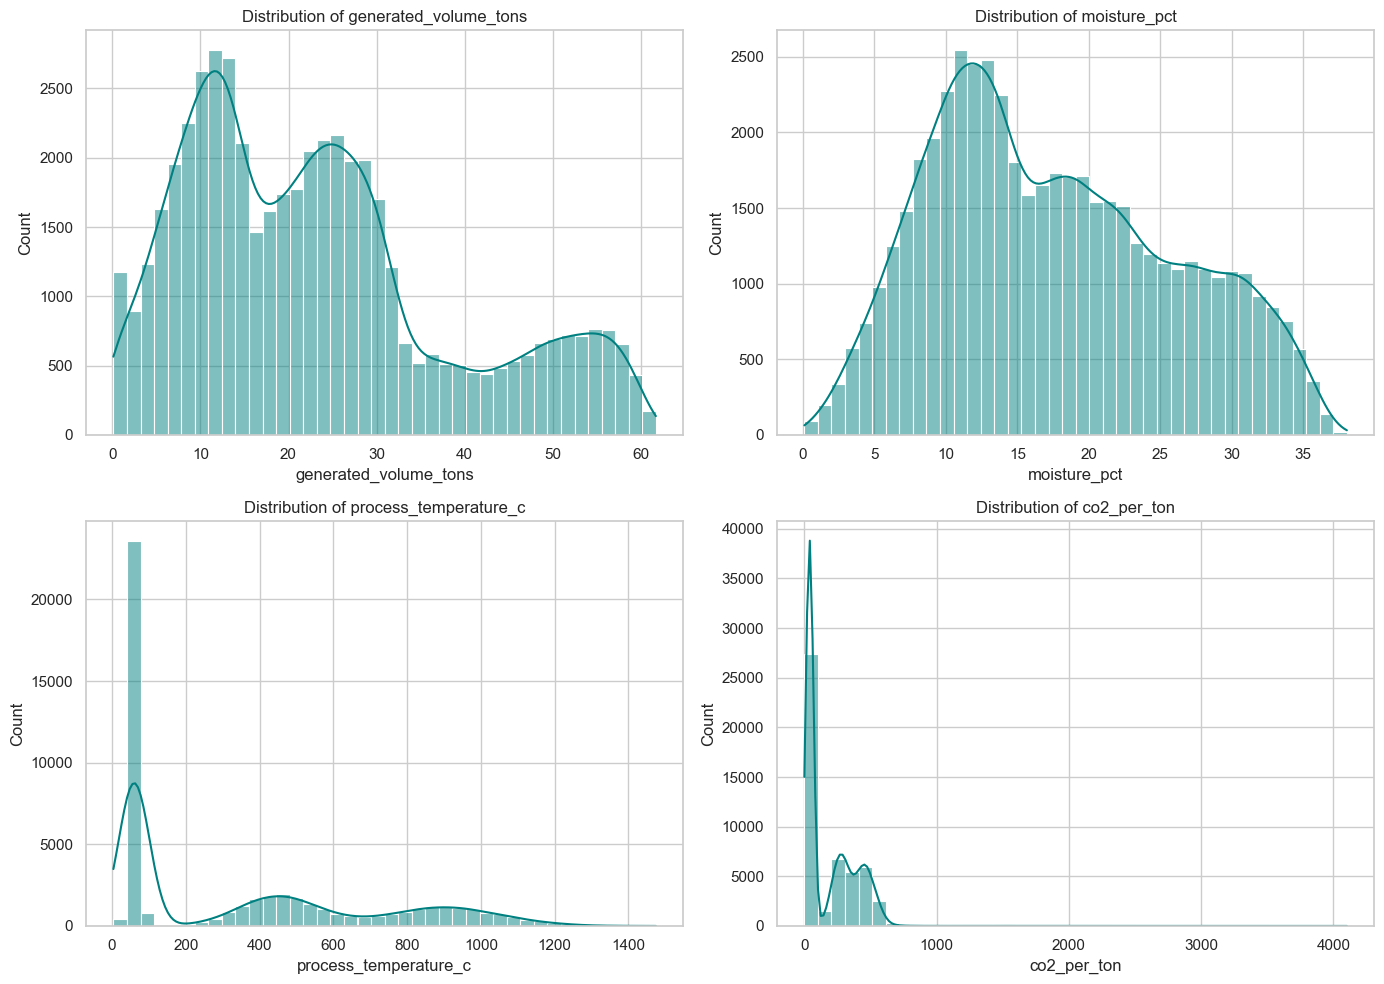

In [4]:
numeric_cols = ["generated_volume_tons", "moisture_pct", "process_temperature_c", "co2_emissions_kg", "co2_per_ton"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()
for ax, col in zip(axes, ["generated_volume_tons", "moisture_pct", "process_temperature_c", "co2_per_ton"]):
    sns.histplot(df[col], bins=40, kde=True, ax=ax, color="teal")
    ax.set_title(f"Distribution of {col}")
plt.tight_layout()
fig.savefig(figures_dir / "distribucion_numericas.png", dpi=150, bbox_inches="tight")
plt.show()

Figure 1 summarizes the distribution of key numerical features. An examination of the numerical distributions reveals a very pronounced positive skew (right-skewed) in load volumes, indicating that most batches are small or moderate, but with a long tail of high-volume cases. Moisture, on the other hand, exhibits a biologically coherent and more centred distribution. This dimensionality and variance require evolutionary architectures to identify non-linear patterns in order to generalise correctly in the face of high industrial load peaks.


## 3. Categorical Distributions

This section shows class balance across categorical variables, especially reuse_strategy.

Balanced categories make downstream comparisons more reliable and reduce the risk of biased model decisions.

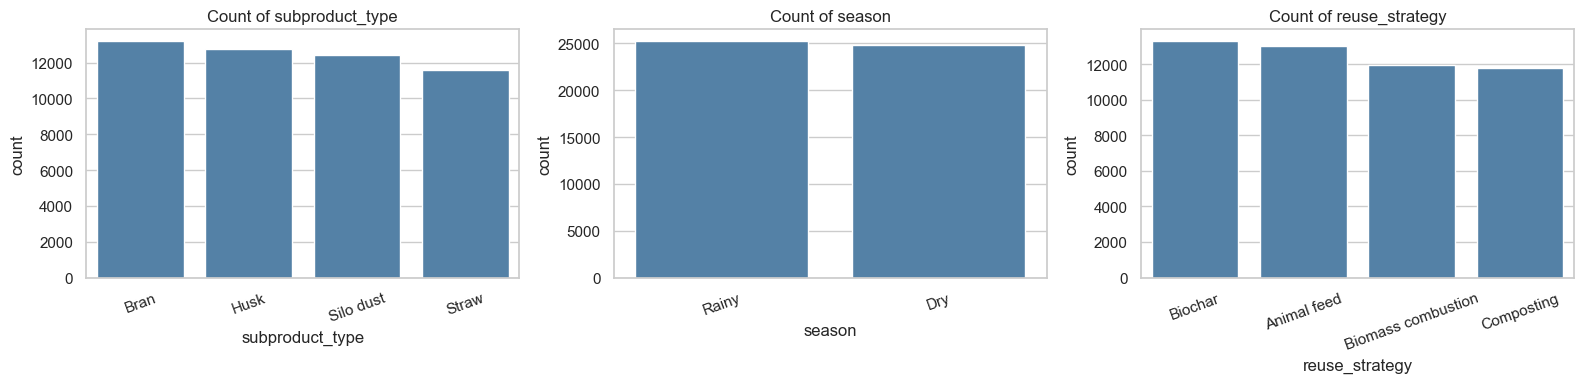

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ["subproduct_type", "season", "reuse_strategy"]):
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, ax=ax, order=order, color="steelblue")
    ax.set_title(f"Count of {col}")
    ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
fig.savefig(figures_dir / "distribucion_categoricas.png", dpi=150, bbox_inches="tight")
plt.show()

Figure 2 shows the frequency of each categorical class. This balance is critical to the success of neuroevolutionary modelling. An unbalanced dataset would prematurely skew the initial populations towards the dominant strategy, causing evolution to stagnate at local optima. The current balance ensures that the algorithm’s natural selection function rewards allocation efficiency rather than the mere statistical probability of the classes. 



## 4. Relationship Between Features and Emissions

Here we explore how operational variables move together with emissions.

The objective is to identify informative patterns that can later guide feature selection and model interpretation.

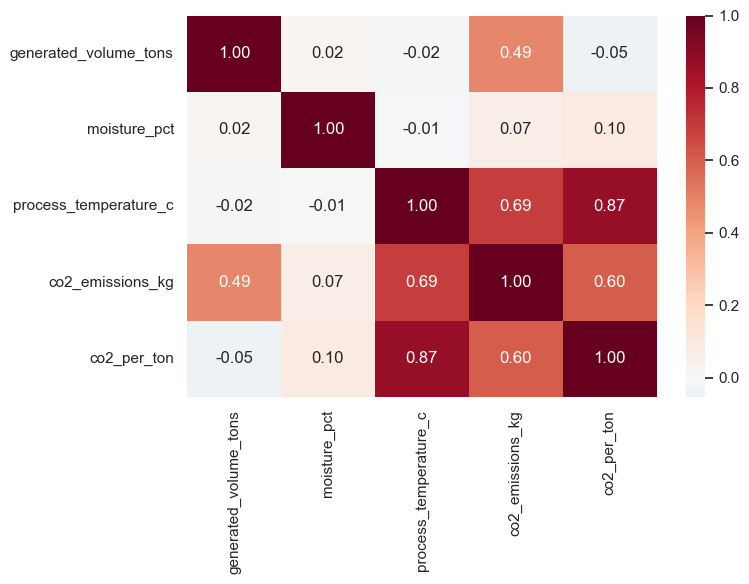

The strongest linear relationship is observed between generated_volume_tons and co2_emissions_kg.


In [6]:
correlation_matrix = df[["generated_volume_tons", "moisture_pct", "process_temperature_c", "co2_emissions_kg", "co2_per_ton"]].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax)
plt.tight_layout()
fig.savefig(figures_dir / "matriz_correlacion.png", dpi=150, bbox_inches="tight")
plt.show()

print("The strongest linear relationship is observed between generated_volume_tons and co2_emissions_kg.")

Figure 3 is a correlation heatmap for numerical variables. To guide the evolution of neural networks, the system requires a clear reward signal. The high variance and strong correlation observed between the operational variables (such as volume and temperature) and the final outcome (measured in ‘co2_per_ton’) provide a suitable fitness environment

Next, boxplots help compare CO2 intensity distributions by strategy and by-product. This view highlights spread, medians, and outliers, which are harder to see in aggregated metrics.

Figure 4 compares CO2 per ton across strategy and subproduct groups.

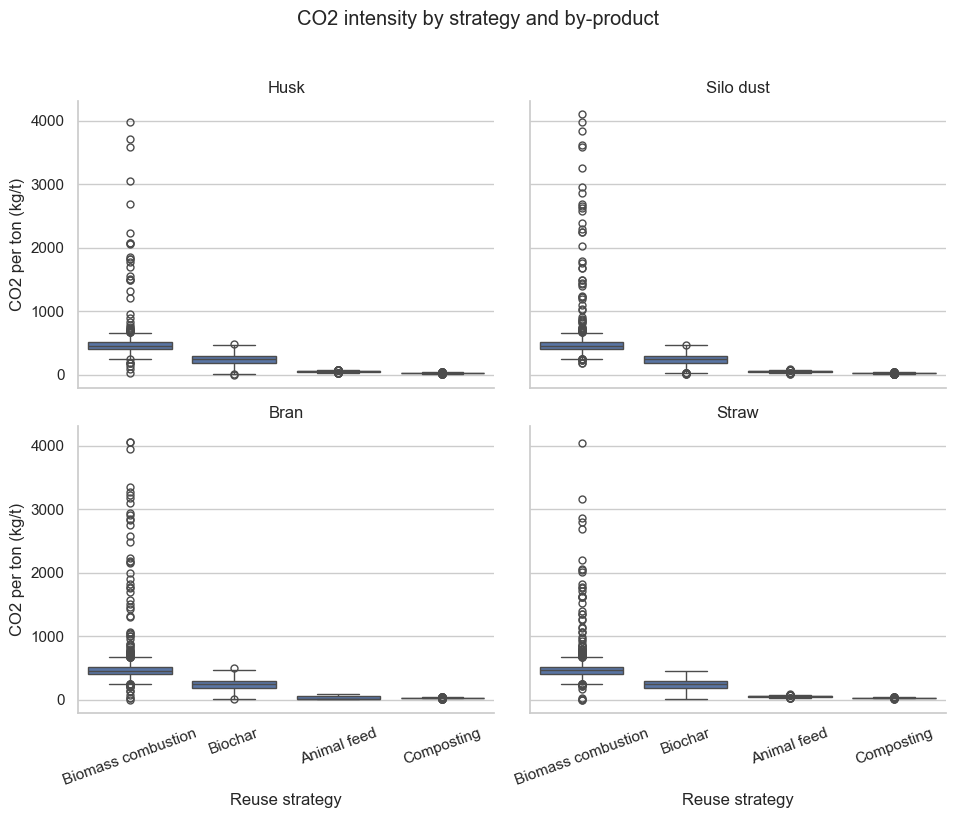

In [7]:
boxplot_grid = sns.catplot(
    data=df,
    x="reuse_strategy",
    y="co2_per_ton",
    col="subproduct_type",
    kind="box",
    col_wrap=2,
    sharey=True,
    height=4,
    aspect=1.2,
)
boxplot_grid.set_titles("{col_name}")
boxplot_grid.set_axis_labels("Reuse strategy", "CO2 per ton (kg/t)")
for ax in boxplot_grid.axes.flatten():
    ax.tick_params(axis="x", rotation=20)
boxplot_grid.fig.suptitle("CO2 intensity by strategy and by-product", y=1.02)
boxplot_grid.fig.tight_layout()
boxplot_grid.fig.savefig(figures_dir / "co2_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()

Box plots confirm that no single strategy is universally superior under all climatic or humidity conditions. This overlap in efficiency justifies the use of a complex neuro-evolutionary approach over simple heuristic rule systems; the algorithm will need to learn topologies that evaluate multivariate interactions in order to truly minimise relative CO₂.
